In [68]:
### to create mba version of the plot using the new code

In [72]:
## automatically reload 
%reload_ext autoreload
%autoreload 2

In [73]:
import matplotlib.pyplot as plt
import numpy as np
import NEOMOD3 as nm3
import NEOfaster as nf
import neoscore as nsc
import S3Marray as sm
import S3M_fullversion as smfull
import trojans as tjn
import neoonlyS3M as neo3m

In [74]:
s3m = sm.define_s3m()

['S1_00.s3m', 'S1_01.s3m', 'S1_02.s3m', 'S1_03.s3m', 'S1_04.s3m', 'S1_05.s3m', 'S1_06.s3m', 'S1_07.s3m', 'S1_08.s3m', 'S1_09.s3m', 'S1_10.s3m', 'S1_11.s3m', 'S1_12.s3m', 'S1_13.s3m']
The final df is done.


In [75]:
s3m,array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m = sm.s3m_array(s3m)

In [78]:
scorer_mba_s3m = nsc.NEOMODScorer(array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m)

Starting computation...


Computing vlambda grid: 100%|██████████| 31/31 [02:10<00:00,  4.22s/it]

Computation complete!


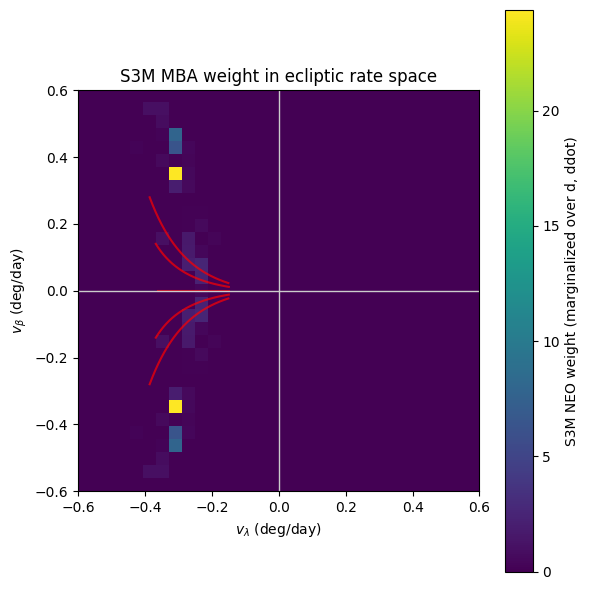

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import neoscore as nsc
from tqdm import tqdm

# Observation params
obstime_str = "2025-09-23T00:00:00"
ra0_deg, dec0_deg = 0.0, 0.0
mag = 24.0

def comp_sum_with_scorer():
    """
    Compute marginalized weights over (vlambda, vbeta) grid using the scorer.
    """
    N_rate = 31
    vlam_min, vlam_max = -0.6, 0.6
    vbet_min, vbet_max = -0.6, 0.6
    vlam_vals = np.linspace(vlam_min, vlam_max, N_rate)
    vbet_vals = np.linspace(vbet_min, vbet_max, N_rate)
    
    K = np.zeros((len(vbet_vals), len(vlam_vals)), dtype=float)
    
    
    for i, vlam in enumerate(tqdm(vlam_vals, desc="Computing vlambda grid")):
        for j, vbet in enumerate(vbet_vals):
            # Convert ecliptic rates to RA/Dec rates
            dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
                ra0_deg, dec0_deg, vlam, vbet, obstime_str
            )
            
            # Use the scorer's marginalization method
            w_int = scorer_mba_s3m.marginalize_over_distance(
                obstime_str=obstime_str,
                ra_deg=ra0_deg,
                dec_deg=dec0_deg,
                dra_deg_per_day=dra,
                ddec_deg_per_day=ddec,
                mag=mag
            )
            
            K[j, i] = w_int
    
    extent = [vlam_vals[0], vlam_vals[-1], vbet_vals[0], vbet_vals[-1]]
    return K, extent, vlam_vals, vbet_vals

# Compute the grid
print("Starting computation...")
K, extent, vlam_vals, vbet_vals = comp_sum_with_scorer()
print("Computation complete!")

# Prediction function 
vE_deg_per_day = 0.986  # Earth's orbital speed

def prediction_vlam_vbet(R_au, i_deg, phi_deg, beta_deg=0.0):
    """Predict ecliptic rates for given orbital parameters."""
    i = np.deg2rad(i_deg)
    phi = np.deg2rad(phi_deg)
    beta = np.deg2rad(beta_deg)
    
    theta = phi - np.arcsin(np.sin(phi) / R_au)
    Delta = np.sqrt(R_au**2 + 1.0 - 2.0 * R_au * np.cos(theta))
    
    v_factor = vE_deg_per_day / np.sqrt(R_au)
    vx = v_factor * np.cos(i) * np.sin(theta)
    vy = v_factor * np.cos(i) * np.cos(theta)
    vz = v_factor * np.sin(i)
    
    vlam = (np.sin(phi) * vx + np.cos(phi) * (vy - vE_deg_per_day)) / Delta
    vbet = (-np.sin(beta) * np.cos(phi) * vx
            + np.sin(beta) * np.sin(phi) * (vy - vE_deg_per_day)
            + np.cos(beta) * vz) / Delta
    
    return vlam, vbet

# Generate prediction curves for different inclinations
phi_deg = 0.0  # opposition
beta_deg = 0.0  # on the ecliptic
i_list = np.arange(-10.0, 15.0, 5.0)  # -10, -5, 0, 5, 10
R_vals = np.linspace(1.5, 4.5, 800)  # AU

i_lines = []
for i_deg in i_list:
    vlam_arr = []
    vbet_arr = []
    for R in R_vals:
        vlam, vbet = prediction_vlam_vbet(R, i_deg, phi_deg, beta_deg)
        vlam_arr.append(vlam)
        vbet_arr.append(vbet)
    i_lines.append((np.array(vlam_arr), np.array(vbet_arr), i_deg))


plt.figure(figsize=(6.0, 6.0))
im = plt.imshow(K, origin="lower", extent=extent, cmap="viridis", aspect="equal")
plt.colorbar(label="S3M NEO weight (marginalized over d, ddot)")

# Plot prediction curves
for vlam_arr, vbet_arr, i_deg in i_lines:
    plt.plot(vlam_arr, vbet_arr, 'r-', lw=1.5, alpha=0.7, 
             label=f'i={i_deg}°' if i_deg == i_list[0] else '')

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.xlim(-0.6, 0.6)
plt.ylim(-0.6, 0.6)
plt.title("S3M MBA weight in ecliptic rate space")
plt.tight_layout()
plt.show()

In [50]:
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import get_sun, SkyCoord

import neoscore as nsc  

def anti_sun_radec_icrs(obstime_str):
    """
    Return anti-Sun direction as (ra_deg, dec_deg) in ICRS at obstime.
    Get Sun direction in ICRS, negate cartesian, convert back to spherical.
    """
    t = Time(obstime_str)
    sun = get_sun(t).icrs

    # Sun cartesian unit vector 
    cart = sun.cartesian

    # Built anti-sun as cartesian in ICRS, then forced spherical representation
    anti = SkyCoord(
        x=-cart.x, y=-cart.y, z=-cart.z,
        representation_type="cartesian",
        frame="icrs",
        obstime=t
    ).icrs  # it should be an ICRS SkyCoord

    # Converting to spherical quantities
    ra = anti.spherical.lon.to_value(u.deg)   # RA
    dec = anti.spherical.lat.to_value(u.deg)  # Dec
    return ra, dec


def vector_test(scorer, obstime_str, d_au=1.5, ddot_kms=0.0, dt_sec=600.0):
    """
    Anti-sun pointing, vlam=vbeta=0, known d and ddot.
    Prints vectors and small-dt angular drift.
    """

    # 1) Anti-Sun pointing in RA/Dec
    ra0_deg, dec0_deg = anti_sun_radec_icrs(obstime_str)

    # 2) Given ecliptic rates
    vlam = 0.0
    vbet = 0.0

    # 3) Convert (vlam, vbet) -> (dra, ddec) using the function from neoscore.py
    dra_deg_day, ddec_deg_day = nsc.ecliptic_rates_to_radec_rates1(
        ra0_deg, dec0_deg, vlam, vbet, obstime_str
    )

    # 4) Build geocentric state like the scorer does
    l_hat, v_hat = scorer._compute_unit_vectors(ra0_deg, dec0_deg, dra_deg_day, ddec_deg_day)

    # In the class, _observables_to_geocentric_state expects ddot_kms and d_au to behave like scalars.
    r_geo, v_geo = scorer._observables_to_geocentric_state(l_hat, v_hat, d_au, ddot_kms)

    # Make 1D vectors
    l_hat = np.asarray(l_hat).reshape(3,)
    v_hat = np.asarray(v_hat).reshape(3,)
    r_geo = np.asarray(r_geo).reshape(-1, 3)[0]   
    v_geo = np.asarray(v_geo).reshape(-1, 3)[0]

    # 5) Expected Line of Sight vector from (ra0,dec0)
    ra = np.deg2rad(ra0_deg)
    dec = np.deg2rad(dec0_deg)
    expected = np.array([np.cos(dec)*np.cos(ra),
                         np.cos(dec)*np.sin(ra),
                         np.sin(dec)], dtype=float)

    l_hat_n = l_hat / np.linalg.norm(l_hat)
    expected_n = expected / np.linalg.norm(expected)

    dot = float(np.clip(np.dot(l_hat_n, expected_n), -1.0, 1.0))
    ang_deg = np.rad2deg(np.arccos(dot))

    # 6) Check the conversion back: RA/Dec rates -> ecliptic rates (should come back as 0, if not Panik)
    vlam_back, vbet_back = nsc.radec_rates_to_ecliptic_rates(
        ra0_deg, dec0_deg, dra_deg_day, ddec_deg_day
    )

    # 7) Propagation drift check
    r2 = r_geo + v_geo * dt_sec
    u1 = r_geo / np.linalg.norm(r_geo)
    u2 = r2 / np.linalg.norm(r2)
    drift_deg = np.rad2deg(np.arccos(float(np.clip(np.dot(u1, u2), -1.0, 1.0))))

    print("anti-Sun, vlam=vbeta=0")
    print(f"obstime: {obstime_str}")
    print(f"anti-sun RA,Dec (deg): {ra0_deg:.6f}, {dec0_deg:.6f}")
    print()
    print("Input ecliptic rates (deg/day):")
    print(f"  vlam={vlam:.6f}, vbeta={vbet:.6f}")
    print("Converted ICRS rates (deg/day):")
    print(f"  dra={dra_deg_day:.12e}, ddec={ddec_deg_day:.12e}")
    print("Returned ecliptic rates (deg/day):")
    print(f"  vlam_back={float(vlam_back):.12e}, vbeta_back={float(vbet_back):.12e}")
    print()
    print("LOS unit vector check:")
    print(f"  l_hat    = {l_hat_n}")
    print(f"  expected = {expected_n}")
    print(f"  angle(l_hat, expected) [deg] = {ang_deg:.12e}")
    print()
    print(f"Geocentric state at d={d_au:.3f} AU, ddot={ddot_kms:.3f} km/s:")
    print(f"  r_geo (km)  = {r_geo}")
    print(f"  v_geo (km/s)= {v_geo}")
    print(f"Direction drift over dt={dt_sec:.1f} s (deg): {drift_deg:.12e}")

    return {
        "ra0_deg": ra0_deg, "dec0_deg": dec0_deg,
        "dra_deg_day": dra_deg_day, "ddec_deg_day": ddec_deg_day,
        "vlam_back": float(vlam_back), "vbet_back": float(vbet_back),
        "angle_deg": ang_deg, "drift_deg": drift_deg,
        "r_geo": r_geo, "v_geo": v_geo,
    }



out = vector_test(scorer_mba_s3m, obstime_str, d_au=1.5, ddot_kms=0.0, dt_sec=600.0)


anti-Sun, vlam=vbeta=0
obstime: 2025-09-23T00:00:00
anti-sun RA,Dec (deg): 53.359612, 17.899506

Input ecliptic rates (deg/day):
  vlam=0.000000, vbeta=0.000000
Converted ICRS rates (deg/day):
  dra=-7.848489312584e-05, ddec=-1.792461499022e-05
Returned ecliptic rates (deg/day):
  vlam_back=-1.117052181763e-04, vbeta_back=1.210547929444e-08

LOS unit vector check:
  l_hat    = [0.56790421 0.76355862 0.30734841]
  expected = [0.56790421 0.76355862 0.30734841]
  angle(l_hat, expected) [deg] = 0.000000000000e+00

Geocentric state at d=1.500 AU, ddot=0.000 km/s:
  r_geo (km)  = [1.27435891e+08 1.71340115e+08 6.89680021e+07]
  v_geo (km/s)= [ 0.0030037  -0.00192281 -0.00077318]
Direction drift over dt=600.0 s (deg): 8.537736462516e-07


In [81]:
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import get_sun, SkyCoord

import neoscore as nsc  

def anti_sun_radec_icrs(obstime_str):
    """
    Return anti-Sun direction as (ra_deg, dec_deg) in ICRS at obstime.
    Get Sun direction in ICRS, negate cartesian, convert back to spherical.
    """
    t = Time(obstime_str)
    sun = get_sun(t).gcrs

    # Sun cartesian unit vector 
    cart = sun.cartesian

    # Built anti-sun as cartesian in ICRS, then forced spherical representation
    anti = SkyCoord(
        x=-cart.x, y=-cart.y, z=-cart.z,
        representation_type="cartesian",
        frame="gcrs",
        obstime=t
    )  # it should be an ICRS SkyCoord

    # Converting to spherical quantities
    ra = anti.spherical.lon.to_value(u.deg)   # RA
    dec = anti.spherical.lat.to_value(u.deg)  # Dec
    return ra, dec


def vector_test(scorer, obstime_str, d_au=1.5, ddot_kms=0.0, dt_sec=600.0):
    """
    Anti-sun pointing, vlam=vbeta=0, known d and ddot.
    Prints vectors and small-dt angular drift.
    """

    # 1) Anti-Sun pointing in RA/Dec
    ra0_deg, dec0_deg = anti_sun_radec_icrs(obstime_str)

    # 2) Given ecliptic rates
    vlam = 0.0
    vbet = 0.0

    # 3) Convert (vlam, vbet) -> (dra, ddec) using the function from neoscore.py
    dra_deg_day, ddec_deg_day = nsc.ecliptic_rates_to_radec_rates1(
        ra0_deg, dec0_deg, vlam, vbet, obstime_str
    )

    # 4) Build geocentric state like the scorer does
    l_hat, v_hat = scorer._compute_unit_vectors(ra0_deg, dec0_deg, dra_deg_day, ddec_deg_day)

    # In the class, _observables_to_geocentric_state expects ddot_kms and d_au to behave like scalars.
    r_geo, v_geo = scorer._observables_to_geocentric_state(l_hat, v_hat, d_au, ddot_kms)

    # Make 1D vectors
    l_hat = np.asarray(l_hat).reshape(3,)
    v_hat = np.asarray(v_hat).reshape(3,)
    r_geo = np.asarray(r_geo).reshape(-1, 3)[0]   
    v_geo = np.asarray(v_geo).reshape(-1, 3)[0]

    # 5) Expected Line of Sight vector from (ra0,dec0)
    ra = np.deg2rad(ra0_deg)
    dec = np.deg2rad(dec0_deg)
    expected = np.array([np.cos(dec)*np.cos(ra),
                         np.cos(dec)*np.sin(ra),
                         np.sin(dec)], dtype=float)

    l_hat_n = l_hat / np.linalg.norm(l_hat)
    expected_n = expected / np.linalg.norm(expected)

    dot = float(np.clip(np.dot(l_hat_n, expected_n), -1.0, 1.0))
    ang_deg = np.rad2deg(np.arccos(dot))

    # 6) Check the conversion back: RA/Dec rates -> ecliptic rates (should come back as 0, if not Panik)
    vlam_back, vbet_back = nsc.radec_rates_to_ecliptic_rates(
        ra0_deg, dec0_deg, dra_deg_day, ddec_deg_day
    )

    # 7) Propagation drift check
    r2 = r_geo + v_geo * dt_sec
    u1 = r_geo / np.linalg.norm(r_geo)
    u2 = r2 / np.linalg.norm(r2)
    drift_deg = np.rad2deg(np.arccos(float(np.clip(np.dot(u1, u2), -1.0, 1.0))))

    print("anti-Sun, vlam=vbeta=0")
    print(f"obstime: {obstime_str}")
    print(f"anti-sun RA,Dec (deg): {ra0_deg:.6f}, {dec0_deg:.6f}")
    print()
    print("Input ecliptic rates (deg/day):")
    print(f"  vlam={vlam:.6f}, vbeta={vbet:.6f}")
    print("Converted ICRS rates (deg/day):")
    print(f"  dra={dra_deg_day:.12e}, ddec={ddec_deg_day:.12e}")
    print("Returned ecliptic rates (deg/day):")
    print(f"  vlam_back={float(vlam_back):.12e}, vbeta_back={float(vbet_back):.12e}")
    print()
    print("LOS unit vector check:")
    print(f"  l_hat    = {l_hat_n}")
    print(f"  expected = {expected_n}")
    print(f"  angle(l_hat, expected) [deg] = {ang_deg:.12e}")
    print()
    print(f"Geocentric state at d={d_au:.3f} AU, ddot={ddot_kms:.3f} km/s:")
    print(f"  r_geo (km)  = {r_geo}")
    print(f"  v_geo (km/s)= {v_geo}")
    print(f"Direction drift over dt={dt_sec:.1f} s (deg): {drift_deg:.12e}")

    return {
        "ra0_deg": ra0_deg, "dec0_deg": dec0_deg,
        "dra_deg_day": dra_deg_day, "ddec_deg_day": ddec_deg_day,
        "vlam_back": float(vlam_back), "vbet_back": float(vbet_back),
        "angle_deg": ang_deg, "drift_deg": drift_deg,
        "r_geo": r_geo, "v_geo": v_geo,
    }



out = vector_test(scorer_mba_s3m, obstime_str, d_au=1.5, ddot_kms=0.0, dt_sec=600.0)


anti-Sun, vlam=vbeta=0
obstime: 2025-09-23T00:00:00
anti-sun RA,Dec (deg): 359.881947, -0.051431

Input ecliptic rates (deg/day):
  vlam=0.000000, vbeta=0.000000
Converted ICRS rates (deg/day):
  dra=0.000000000000e+00, ddec=0.000000000000e+00
Returned ecliptic rates (deg/day):
  vlam_back=4.028681508555e-05, vbeta_back=3.113450785642e-08

LOS unit vector check:
  l_hat    = [ 9.99997474e-01 -2.06041694e-03 -8.97645677e-04]
  expected = [ 9.99997474e-01 -2.06041694e-03 -8.97645677e-04]
  angle(l_hat, expected) [deg] = 0.000000000000e+00

Geocentric state at d=1.500 AU, ddot=0.000 km/s:
  r_geo (km)  = [ 2.24396239e+08 -4.62350980e+05 -2.01428823e+05]
  v_geo (km/s)= [0. 0. 0.]
Direction drift over dt=600.0 s (deg): 8.537736462516e-07


#### Same thing but not converting sun position to ICRS in order to check the conversions

In [60]:
from astropy.coordinates import GeocentricTrueEcliptic

def radec_rates_to_ecliptic_rates_at_obstime(ra_deg, dec_deg, dra_deg_day, ddec_deg_day, obstime_str):
    t = Time(obstime_str)
    sc_eq = SkyCoord(
        ra=ra_deg * u.deg,
        dec=dec_deg * u.deg,
        pm_ra_cosdec=dra_deg_day * u.deg/u.day,
        pm_dec=ddec_deg_day * u.deg/u.day,
        frame=GCRS(obstime=t)
    )
    sc_ecl = sc_eq.transform_to(GeocentricTrueEcliptic(obstime=t))
    vlam = sc_ecl.pm_lon_coslat.to(u.deg/u.day).value
    vbeta = sc_ecl.pm_lat.to(u.deg/u.day).value
    return vlam, vbeta


In [67]:
from astropy.coordinates import GCRS

# Get sun coords in GCRS (no ICRS forced conversion)
def anti_sun_radec_gcrs(obstime_str):
    t = Time(obstime_str)
    sun_gcrs = get_sun(t).transform_to(GCRS(obstime=t))
    cart = sun_gcrs.cartesian

    anti_gcrs = SkyCoord(
        x=-cart.x, y=-cart.y, z=-cart.z,
        representation_type="cartesian",
        frame=GCRS(obstime=t)
    )

    ra = anti_gcrs.spherical.lon.to_value(u.deg)
    dec = anti_gcrs.spherical.lat.to_value(u.deg)
    return ra, dec

# Conversion of RA/dec rates to ecliptic using obstime instead of without
def radec_rates_to_ecliptic_rates_at_obstime(ra_deg, dec_deg, dra_deg_day, ddec_deg_day, obstime_str):
    t = Time(obstime_str)
    sc_eq = SkyCoord(
        ra=ra_deg * u.deg,
        dec=dec_deg * u.deg,
        pm_ra_cosdec=dra_deg_day * u.deg/u.day,
        pm_dec=ddec_deg_day * u.deg/u.day,
        frame=GCRS(obstime=t)
    )
    sc_ecl = sc_eq.transform_to(GeocentricTrueEcliptic(obstime=t))
    vlam = sc_ecl.pm_lon_coslat.to(u.deg/u.day).value
    vbeta = sc_ecl.pm_lat.to(u.deg/u.day).value
    return vlam, vbeta


def vector_test(scorer, obstime_str, vlam=0.0, vbet=0.0, d_au=1.5, ddot_kms=0.0, dt_sec=600.0):
    # Anti-Sun pointing in RA/Dec (GCRS)
    ra0_deg, dec0_deg = anti_sun_radec_gcrs(obstime_str)

    # Convert (vlam, vbet) -> (dra, ddec) using the neoscorer function
    dra_deg_day, ddec_deg_day = nsc.ecliptic_rates_to_radec_rates1(
        ra0_deg, dec0_deg, vlam, vbet, obstime_str
    )

    # Build geocentric state using functions from scorer
    l_hat, v_hat = scorer._compute_unit_vectors(ra0_deg, dec0_deg, dra_deg_day, ddec_deg_day)
    r_geo, v_geo = scorer._observables_to_geocentric_state(l_hat, v_hat, d_au, ddot_kms)

    # Reshape
    l_hat = np.asarray(l_hat).reshape(3,)
    r_geo = np.asarray(r_geo).reshape(-1, 3)[0]
    v_geo = np.asarray(v_geo).reshape(-1, 3)[0]

    # Expected LOS vector from (ra0, dec0)
    ra = np.deg2rad(ra0_deg)
    dec = np.deg2rad(dec0_deg)
    expected = np.array([np.cos(dec)*np.cos(ra),
                         np.cos(dec)*np.sin(ra),
                         np.sin(dec)], dtype=float)

    l_hat_n = l_hat / np.linalg.norm(l_hat)
    expected_n = expected / np.linalg.norm(expected)
    ang_deg = np.rad2deg(np.arccos(float(np.clip(np.dot(l_hat_n, expected_n), -1.0, 1.0))))

    # Convert RA/Dec rates -> ecliptic rates (at same obstime, in GCRS)
    vlam_back, vbet_back = radec_rates_to_ecliptic_rates_at_obstime(
        ra0_deg, dec0_deg, dra_deg_day, ddec_deg_day, obstime_str
    )

    # Drift check
    r2 = r_geo + v_geo * dt_sec
    u1 = r_geo / np.linalg.norm(r_geo)
    u2 = r2 / np.linalg.norm(r2)
    drift_deg = np.rad2deg(np.arccos(float(np.clip(np.dot(u1, u2), -1.0, 1.0))))

    
    print("=== anti-Sun rate sanity test (GCRS) ===")
    print(f"obstime: {obstime_str}")
    print(f"anti-sun RA,Dec (deg): {ra0_deg:.6f}, {dec0_deg:.6f}")
    print()
    print("Input ecliptic rates (deg/day):")
    print(f"  vlam={vlam:.6f}, vbeta={vbet:.6f}")
    print("Converted equatorial rates (deg/day):")
    print(f"  dra={dra_deg_day:.12e}, ddec={ddec_deg_day:.12e}")
    print("Returned ecliptic rates (deg/day):")
    print(f"  vlam_back={float(vlam_back):.12e}, vbeta_back={float(vbet_back):.12e}")
    print()
    print("LOS unit vector check:")
    print(f"  angle(l_hat, expected) [deg] = {ang_deg:.12e}")
    print()
    print(f"Geocentric state at d={d_au:.3f} AU, ddot={ddot_kms:.3f} km/s:")
    print(f"  r_geo (km)  = {r_geo}")
    print(f"  v_geo (km/s)= {v_geo}")
    print(f"Direction drift over dt={dt_sec:.1f} s (deg): {drift_deg:.12e}")

    return {
        "ra0_deg": ra0_deg, "dec0_deg": dec0_deg,
        "dra_deg_day": dra_deg_day, "ddec_deg_day": ddec_deg_day,
        "vlam_back": float(vlam_back), "vbet_back": float(vbet_back),
        "angle_deg": ang_deg, "drift_deg": drift_deg,
        "r_geo": r_geo, "v_geo": v_geo,
    }


# For v_lam, v_beta = (0,0) 
out00 = vector_test(scorer_mba_s3m, obstime_str, vlam=0.0, vbet=0.0)
print()
print()
print()
# For v_lam, v_beta = (30,45) 
out3045 = vector_test(scorer_mba_s3m, obstime_str, vlam=30.0, vbet=45.0)


=== anti-Sun rate sanity test (GCRS) ===
obstime: 2025-09-23T00:00:00
anti-sun RA,Dec (deg): 359.881947, -0.051431

Input ecliptic rates (deg/day):
  vlam=0.000000, vbeta=0.000000
Converted equatorial rates (deg/day):
  dra=9.233257863340e-08, ddec=6.076332789206e-08
Returned ecliptic rates (deg/day):
  vlam_back=4.039569997012e-05, vbeta_back=5.015581409794e-08

LOS unit vector check:
  angle(l_hat, expected) [deg] = 0.000000000000e+00

Geocentric state at d=1.500 AU, ddot=0.000 km/s:
  r_geo (km)  = [ 2.24396239e+08 -4.62350980e+05 -2.01428823e+05]
  v_geo (km/s)= [1.10960792e-08 4.18536955e-06 2.75436615e-06]
Direction drift over dt=600.0 s (deg): 0.000000000000e+00



=== anti-Sun rate sanity test (GCRS) ===
obstime: 2025-09-23T00:00:00
anti-sun RA,Dec (deg): 359.881947, -0.051431

Input ecliptic rates (deg/day):
  vlam=30.000000, vbeta=45.000000
Converted equatorial rates (deg/day):
  dra=9.624532877448e+00, ddec=5.321991342202e+01
Returned ecliptic rates (deg/day):
  vlam_back=2.

In [162]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import get_sun, SkyCoord
from tqdm import tqdm
import time



def anti_sun_radec_icrs(obstime_str):
    """Anti-sun RA/Dec in GCRS at obstime."""
    t = Time(obstime_str)
    sun = get_sun(t)
    cart = sun.cartesian
    anti = SkyCoord(
        x=-cart.x, y=-cart.y, z=-cart.z,
        representation_type="cartesian",
        frame="gcrs",
        obstime=t
    )
    return (
        anti.spherical.lon.to_value(u.deg),
        anti.spherical.lat.to_value(u.deg),
    )



ra0_deg, dec0_deg = anti_sun_radec_icrs(obstime_str)

print(f"obstime = {obstime_str}")
print(f"anti-sun RA,Dec (deg) = {ra0_deg:.6f}, {dec0_deg:.6f}")
# --- 10-second conversion consistency check at anti-sun ---

# pick a representative ecliptic rate
vlam0, vbet0 = -0.2, 0.0  # deg/day

# forward: (vlam,vbet) -> (dra,ddec)
dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
    ra0_deg, dec0_deg, vlam0, vbet0, obstime_str
)

# backward: (dra,ddec) -> (vlam_back,vbet_back) at SAME obstime
vlam_back, vbet_back = radec_rates_to_ecliptic_rates_at_obstime(
    ra0_deg, dec0_deg, dra, ddec, obstime_str
)

print("vlam0:", vlam0)
print("vlam_back:", vlam_back)
print("diff (vlam_back - vlam0):", vlam_back - vlam0)
print("vbet0:", vbet0, "vbet_back:", vbet_back)



# Grids

d_grid = np.linspace(1.5, 4.5, 60)          # AU
vlam_grid = np.linspace(-0.6, 0.6, 241)     # deg/day
vbeta_fixed = 0.0
ddot_fixed = 0.0                            

W = np.zeros((len(d_grid), len(vlam_grid)), dtype=float)


# Scan with fixed ddot = 0

t0 = time.perf_counter()

for idd, d_au in enumerate(tqdm(d_grid, desc="Scanning distance d", unit="AU")):
    for iv, vlam in enumerate(vlam_grid):
        dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
            ra0_deg, dec0_deg, vlam, vbeta_fixed, obstime_str
        )

        out = scorer_mba_s3m.compute_score(
            obstime_str=obstime_str,
            ra_deg=ra0_deg,
            dec_deg=dec0_deg,
            dra_deg_per_day=dra,
            ddec_deg_per_day=ddec,
            mag=mag,
            d_au=d_au,
            ddot_kms=ddot_fixed
        )

        W[idd, iv] = out["score"]

t1 = time.perf_counter()
print(f"\nTotal runtime: {(t1 - t0)/60:.2f} minutes")


best_idx = np.argmax(W, axis=1)
best_vlam = vlam_grid[best_idx]
best_w = W[np.arange(len(d_grid)), best_idx]



obstime = 2025-09-23T00:00:00
anti-sun RA,Dec (deg) = 359.881947, -0.051431
vlam0: -0.2
vlam_back: -0.19995971318339506
diff (vlam_back - vlam0): 4.0286816604950815e-05
vbet0: 0.0 vbet_back: 3.113397578260749e-08


Scanning distance d: 100%|██████████| 60/60 [02:27<00:00,  2.46s/AU]


Total runtime: 2.46 minutes


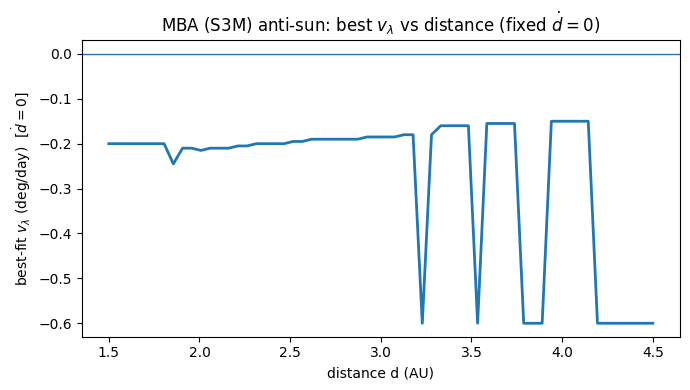

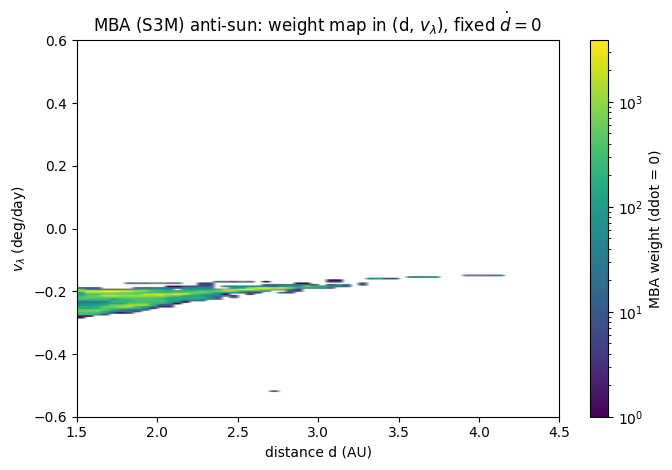

Peak weights: min=0.000e+00, max=3.846e+03


In [163]:

plt.figure(figsize=(7, 4))
plt.plot(d_grid, best_vlam, lw=2)
plt.axhline(0.0, lw=1)
plt.xlabel("distance d (AU)")
plt.ylabel(r"best-fit $v_\lambda$ (deg/day)  [$\dot d = 0$]")
plt.title("MBA (S3M) anti-sun: best $v_\\lambda$ vs distance (fixed $\dot d=0$)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.8))
plt.imshow(
    W.T,
    origin="lower",
    aspect="auto",
    extent=[d_grid[0], d_grid[-1], vlam_grid[0], vlam_grid[-1]],
    norm = "log"
)
plt.colorbar(label="MBA weight (ddot = 0)")
plt.xlabel("distance d (AU)")
plt.ylabel(r"$v_\lambda$ (deg/day)")
plt.title("MBA (S3M) anti-sun: weight map in (d, $v_\\lambda$), fixed $\dot d=0$")
plt.tight_layout()
plt.show()

print(f"Peak weights: min={best_w.min():.3e}, max={best_w.max():.3e}")


Extracting elements on ridge: 100%|██████████| 48/48 [00:00<00:00, 96.37d/s]


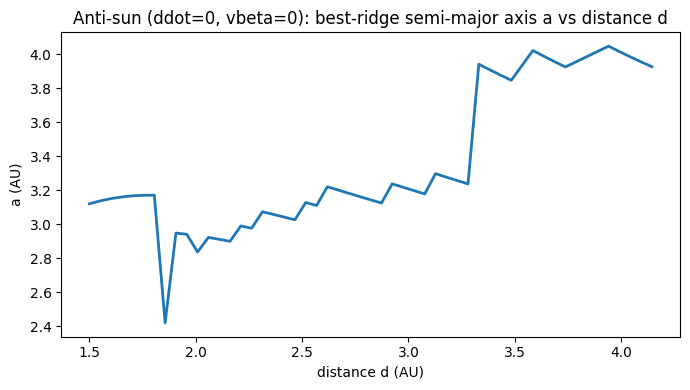

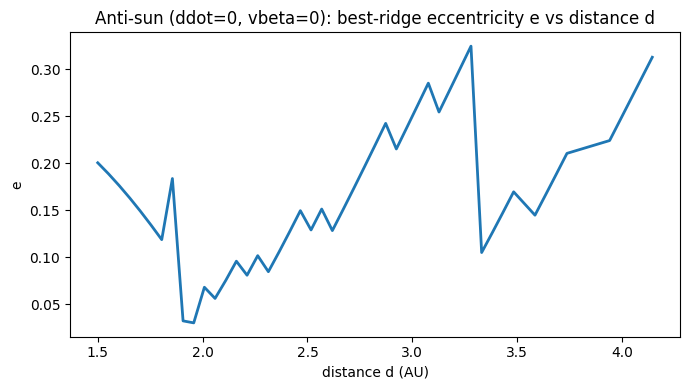

a range: 2.41835842415191 to 4.0486507255779465
e range: 0.029940326647373474 to 0.32434188604997993
i range: 0.0039517998526891205 to 0.005324278746760472
H range: 20.0 to 20.0


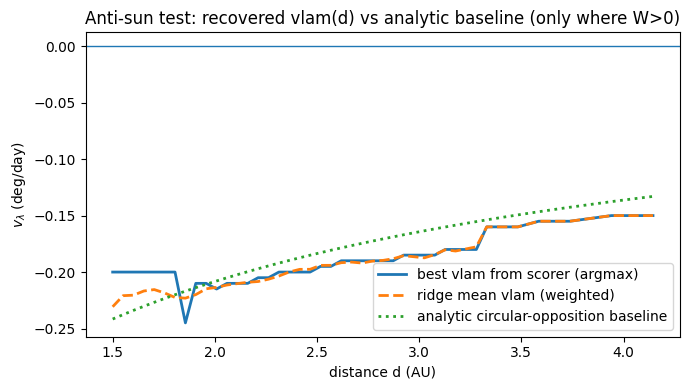

Supported d range: 1.5 to 4.1440677966101696
How many supported points: 48 / 60


In [164]:
# mask unsupported distances 
row_max = W.max(axis=1)
mask = row_max > 0

#for opposition, circular coplanar orbit
vE = 0.986  # deg/day
d = d_grid.copy()
R = 1.0 + d
vlam_pred = vE * (1/np.sqrt(R) - 1.0) / d  # deg/day, negative, |vlam| decreases with d

# using "center of mass" of the ridge instead of argmax
# this avoids bin/edge effects if the ridge is broad
Wpos = W.copy()
Wpos[Wpos < 0] = 0 # negative weight clipped to 0
vlam_mean = np.full(len(d_grid), np.nan)
for k in range(len(d_grid)):
    s = Wpos[k].sum()
    if s > 0:
        vlam_mean[k] = np.sum(vlam_grid * Wpos[k]) / s

#  Extract orbital elements (a,e,i,H) along the best-vlam ridge vs distance 

a_best = np.full(len(d_grid), np.nan)
e_best = np.full(len(d_grid), np.nan)
i_best = np.full(len(d_grid), np.nan)
H_best = np.full(len(d_grid), np.nan)
score_best = np.full(len(d_grid), np.nan)

for k in tqdm(np.where(mask)[0], desc="Extracting elements on ridge", unit="d"):
    d_au = d_grid[k]
    vlam = best_vlam[k]

    # convert (vlam, vbeta_fixed) -> (dra, ddec) at the anti-sun sky position
    dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
        ra0_deg, dec0_deg, vlam, vbeta_fixed, obstime_str
    )

    out = scorer_mba_s3m.compute_score(
        obstime_str=obstime_str,
        ra_deg=ra0_deg,
        dec_deg=dec0_deg,
        dra_deg_per_day=dra,
        ddec_deg_per_day=ddec,
        mag=mag,
        d_au=d_au,
        ddot_kms=ddot_fixed
    )

    score_best[k] = out["score"]
    a_best[k] = out["a"]
    e_best[k] = out["e"]
    i_best[k] = out["i"]
    H_best[k] = out["H"]

# Plot a vs d (only where supported)
plt.figure(figsize=(7,4))
plt.plot(d_grid[mask], a_best[mask], lw=2)
plt.xlabel("distance d (AU)")
plt.ylabel("a (AU)")
plt.title("Anti-sun (ddot=0, vbeta=0): best-ridge semi-major axis a vs distance d")
plt.tight_layout()
plt.show()

# plotting e vs d
plt.figure(figsize=(7,4))
plt.plot(d_grid[mask], e_best[mask], lw=2)
plt.xlabel("distance d (AU)")
plt.ylabel("e")
plt.title("Anti-sun (ddot=0, vbeta=0): best-ridge eccentricity e vs distance d")
plt.tight_layout()
plt.show()



print("a range:", np.nanmin(a_best), "to", np.nanmax(a_best))
print("e range:", np.nanmin(e_best), "to", np.nanmax(e_best))
print("i range:", np.nanmin(i_best), "to", np.nanmax(i_best))
print("H range:", np.nanmin(H_best), "to", np.nanmax(H_best))


# plot comparison only where supported aka no zero
plt.figure(figsize=(7,4))
plt.plot(d_grid[mask], best_vlam[mask], lw=2, label="best vlam from scorer (argmax)")
plt.plot(d_grid[mask], vlam_mean[mask], lw=2, ls="--", label="ridge mean vlam (weighted)")
plt.plot(d_grid[mask], vlam_pred[mask], lw=2, ls=":", label="analytic circular-opposition baseline")

plt.axhline(0, lw=1)
plt.xlabel("distance d (AU)")
plt.ylabel(r"$v_\lambda$ (deg/day)")
plt.title("Anti-sun test: recovered vlam(d) vs analytic baseline (only where W>0)")
plt.legend()
plt.tight_layout()
plt.show()

print("Supported d range:", d_grid[mask].min(), "to", d_grid[mask].max())
print("How many supported points:", mask.sum(), "/", len(mask))


#### same plots but for ddot = -5

In [165]:
def anti_sun_radec_icrs(obstime_str):
    """Anti-sun RA/Dec in GCRS at obstime."""
    t = Time(obstime_str)
    sun = get_sun(t)
    cart = sun.cartesian
    anti = SkyCoord(
        x=-cart.x, y=-cart.y, z=-cart.z,
        representation_type="cartesian",
        frame="gcrs",
        obstime=t
    )
    return (
        anti.spherical.lon.to_value(u.deg),
        anti.spherical.lat.to_value(u.deg),
    )



ra0_deg, dec0_deg = anti_sun_radec_icrs(obstime_str)

print(f"obstime = {obstime_str}")
print(f"anti-sun RA,Dec (deg) = {ra0_deg:.6f}, {dec0_deg:.6f}")

# Grids

d_grid = np.linspace(1.5, 4.5, 60)          # AU
vlam_grid = np.linspace(-0.6, 0.6, 241)     # deg/day
vbeta_fixed = 0.0
ddot_fixed = -5.0                            

W = np.zeros((len(d_grid), len(vlam_grid)), dtype=float)


# Scan with fixed ddot = -5

t0 = time.perf_counter()

for idd, d_au in enumerate(tqdm(d_grid, desc="Scanning distance d", unit="AU")):
    for iv, vlam in enumerate(vlam_grid):
        dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
            ra0_deg, dec0_deg, vlam, vbeta_fixed, obstime_str
        )

        out = scorer_mba_s3m.compute_score(
            obstime_str=obstime_str,
            ra_deg=ra0_deg,
            dec_deg=dec0_deg,
            dra_deg_per_day=dra,
            ddec_deg_per_day=ddec,
            mag=mag,
            d_au=d_au,
            ddot_kms=ddot_fixed
        )

        W[idd, iv] = out["score"]

t1 = time.perf_counter()
print(f"\nTotal runtime: {(t1 - t0)/60:.2f} minutes")


best_idx = np.argmax(W, axis=1)
best_vlam = vlam_grid[best_idx]
best_w = W[np.arange(len(d_grid)), best_idx]



obstime = 2025-09-23T00:00:00
anti-sun RA,Dec (deg) = 359.881947, -0.051431


Scanning distance d: 100%|██████████| 60/60 [02:27<00:00,  2.47s/AU]


Total runtime: 2.47 minutes


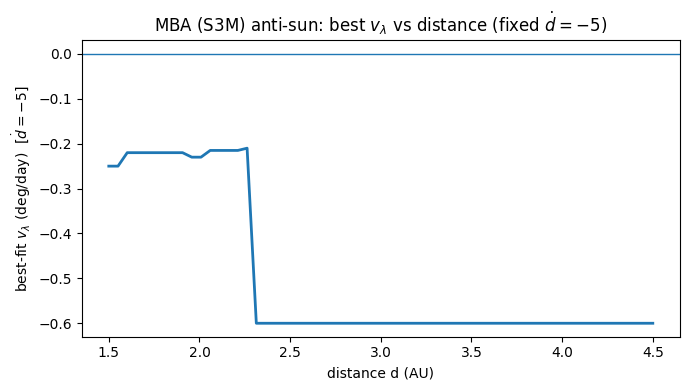

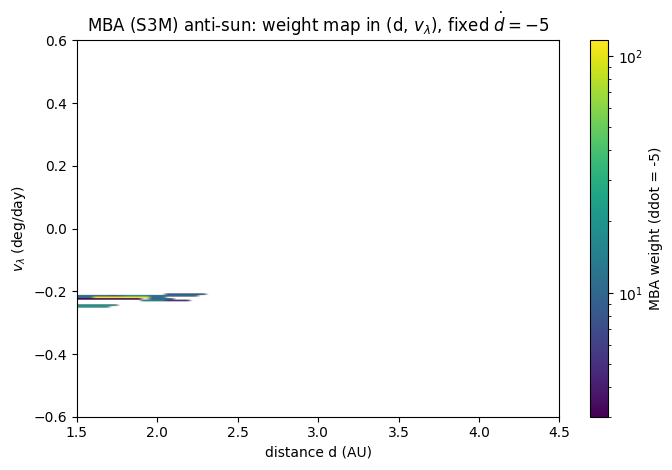

Peak weights: min=0.000e+00, max=1.160e+02


In [166]:

plt.figure(figsize=(7, 4))
plt.plot(d_grid, best_vlam, lw=2)
plt.axhline(0.0, lw=1)
plt.xlabel("distance d (AU)")
plt.ylabel(r"best-fit $v_\lambda$ (deg/day)  [$\dot d = -5$]")
plt.title("MBA (S3M) anti-sun: best $v_\\lambda$ vs distance (fixed $\dot d=-5$)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.8))
plt.imshow(
    W.T,
    origin="lower",
    aspect="auto",
    extent=[d_grid[0], d_grid[-1], vlam_grid[0], vlam_grid[-1]],
    norm = "log"
)
# add norm = "log" to imshow to see in log space
plt.colorbar(label="MBA weight (ddot = -5)")
plt.xlabel("distance d (AU)")
plt.ylabel(r"$v_\lambda$ (deg/day)")
plt.title("MBA (S3M) anti-sun: weight map in (d, $v_\\lambda$), fixed $\dot d=-5$")
plt.tight_layout()
plt.show()

print(f"Peak weights: min={best_w.min():.3e}, max={best_w.max():.3e}")


Extracting elements on ridge: 100%|██████████| 16/16 [00:00<00:00, 94.42d/s]


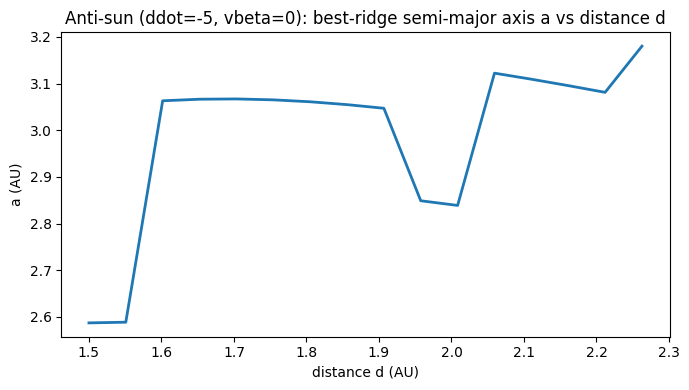

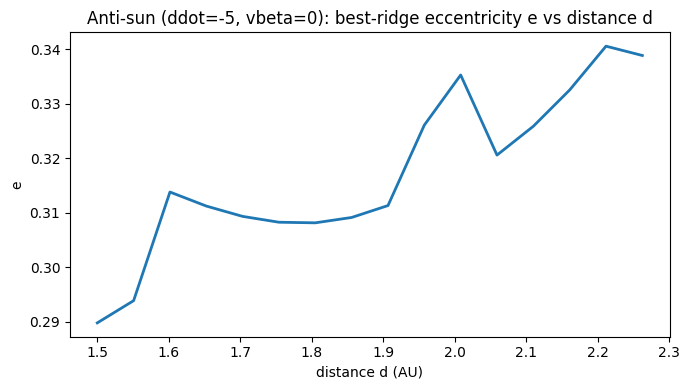

a range: 2.5869205450120307 to 3.1802157048004336
e range: 0.28976737424672194 to 0.3405867609703876
i range: 0.003511861087668004 to 0.0036634749673038138
H range: 20.0 to 20.0


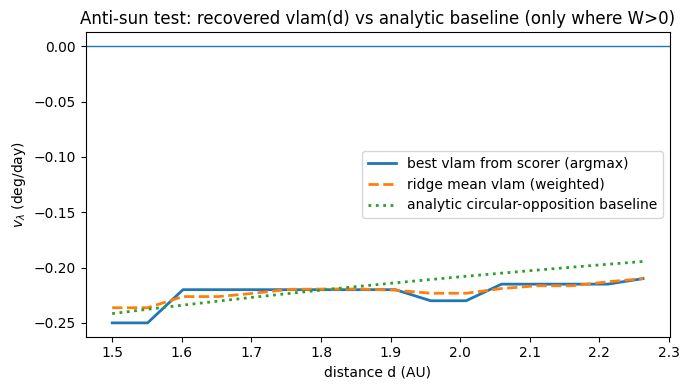

Supported d range: 1.5 to 2.26271186440678
How many supported points: 16 / 60


In [167]:
# mask unsupported distances 
row_max = W.max(axis=1)
mask = row_max > 0

#for opposition, circular coplanar orbit
vE = 0.986  # deg/day
d = d_grid.copy()
R = 1.0 + d
vlam_pred = vE * (1/np.sqrt(R) - 1.0) / d  # deg/day, negative, |vlam| decreases with d

# using "center of mass" of the ridge instead of argmax
# this avoids bin/edge effects if the ridge is broad
Wpos = W.copy()
Wpos[Wpos < 0] = 0 # negative weight clipped to 0
vlam_mean = np.full(len(d_grid), np.nan)
for k in range(len(d_grid)):
    s = Wpos[k].sum()
    if s > 0:
        vlam_mean[k] = np.sum(vlam_grid * Wpos[k]) / s

# Extract orbital elements (a,e,i,H) along the best-vlam ridge vs distance 

a_best = np.full(len(d_grid), np.nan)
e_best = np.full(len(d_grid), np.nan)
i_best = np.full(len(d_grid), np.nan)
H_best = np.full(len(d_grid), np.nan)
score_best = np.full(len(d_grid), np.nan)

for k in tqdm(np.where(mask)[0], desc="Extracting elements on ridge", unit="d"):
    d_au = d_grid[k]
    vlam = best_vlam[k]

    # convert (vlam, vbeta_fixed) -> (dra, ddec) at the anti-sun sky position
    dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
        ra0_deg, dec0_deg, vlam, vbeta_fixed, obstime_str
    )

    out = scorer_mba_s3m.compute_score(
        obstime_str=obstime_str,
        ra_deg=ra0_deg,
        dec_deg=dec0_deg,
        dra_deg_per_day=dra,
        ddec_deg_per_day=ddec,
        mag=mag,
        d_au=d_au,
        ddot_kms=ddot_fixed
    )

    score_best[k] = out["score"]
    a_best[k] = out["a"]
    e_best[k] = out["e"]
    i_best[k] = out["i"]
    H_best[k] = out["H"]

# Plot a vs d (only where supported)
plt.figure(figsize=(7,4))
plt.plot(d_grid[mask], a_best[mask], lw=2)
plt.xlabel("distance d (AU)")
plt.ylabel("a (AU)")
plt.title("Anti-sun (ddot=-5, vbeta=0): best-ridge semi-major axis a vs distance d")
plt.tight_layout()
plt.show()

# plotting e vs d
plt.figure(figsize=(7,4))
plt.plot(d_grid[mask], e_best[mask], lw=2)
plt.xlabel("distance d (AU)")
plt.ylabel("e")
plt.title("Anti-sun (ddot=-5, vbeta=0): best-ridge eccentricity e vs distance d")
plt.tight_layout()
plt.show()



print("a range:", np.nanmin(a_best), "to", np.nanmax(a_best))
print("e range:", np.nanmin(e_best), "to", np.nanmax(e_best))
print("i range:", np.nanmin(i_best), "to", np.nanmax(i_best))
print("H range:", np.nanmin(H_best), "to", np.nanmax(H_best))


# plot comparison only where supported aka no zero
plt.figure(figsize=(7,4))
plt.plot(d_grid[mask], best_vlam[mask], lw=2, label="best vlam from scorer (argmax)")
plt.plot(d_grid[mask], vlam_mean[mask], lw=2, ls="--", label="ridge mean vlam (weighted)")
plt.plot(d_grid[mask], vlam_pred[mask], lw=2, ls=":", label="analytic circular-opposition baseline")

plt.axhline(0, lw=1)
plt.xlabel("distance d (AU)")
plt.ylabel(r"$v_\lambda$ (deg/day)")
plt.title("Anti-sun test: recovered vlam(d) vs analytic baseline (only where W>0)")
plt.legend()
plt.tight_layout()
plt.show()

print("Supported d range:", d_grid[mask].min(), "to", d_grid[mask].max())
print("How many supported points:", mask.sum(), "/", len(mask))


### same plots but ddot = +5

In [168]:
def anti_sun_radec_icrs(obstime_str):
    """Anti-sun RA/Dec in GCRS at obstime."""
    t = Time(obstime_str)
    sun = get_sun(t)
    cart = sun.cartesian
    anti = SkyCoord(
        x=-cart.x, y=-cart.y, z=-cart.z,
        representation_type="cartesian",
        frame="gcrs",
        obstime=t
    )
    return (
        anti.spherical.lon.to_value(u.deg),
        anti.spherical.lat.to_value(u.deg),
    )



ra0_deg, dec0_deg = anti_sun_radec_icrs(obstime_str)

print(f"obstime = {obstime_str}")
print(f"anti-sun RA,Dec (deg) = {ra0_deg:.6f}, {dec0_deg:.6f}")

# Grids

d_grid = np.linspace(1.5, 4.5, 60)          # AU
vlam_grid = np.linspace(-0.6, 0.6, 241)     # deg/day
vbeta_fixed = 0.0
ddot_fixed = 5.0                            

W = np.zeros((len(d_grid), len(vlam_grid)), dtype=float)


# Scan with fixed ddot = -5

t0 = time.perf_counter()

for idd, d_au in enumerate(tqdm(d_grid, desc="Scanning distance d", unit="AU")):
    for iv, vlam in enumerate(vlam_grid):
        dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
            ra0_deg, dec0_deg, vlam, vbeta_fixed, obstime_str
        )

        out = scorer_mba_s3m.compute_score(
            obstime_str=obstime_str,
            ra_deg=ra0_deg,
            dec_deg=dec0_deg,
            dra_deg_per_day=dra,
            ddec_deg_per_day=ddec,
            mag=mag,
            d_au=d_au,
            ddot_kms=ddot_fixed
        )

        W[idd, iv] = out["score"]

t1 = time.perf_counter()
print(f"\nTotal runtime: {(t1 - t0)/60:.2f} minutes")


best_idx = np.argmax(W, axis=1)
best_vlam = vlam_grid[best_idx]
best_w = W[np.arange(len(d_grid)), best_idx]



obstime = 2025-09-23T00:00:00
anti-sun RA,Dec (deg) = 359.881947, -0.051431


Scanning distance d: 100%|██████████| 60/60 [02:28<00:00,  2.47s/AU]


Total runtime: 2.47 minutes


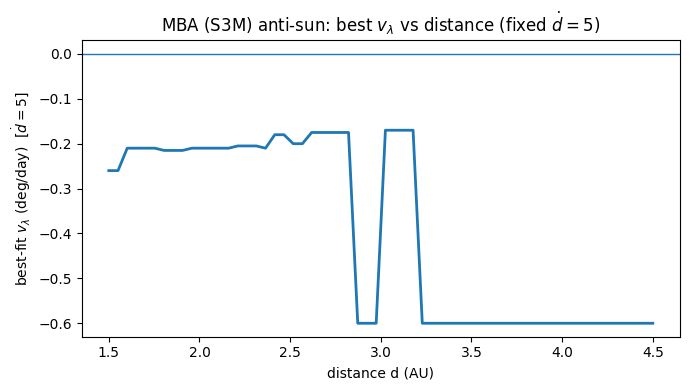

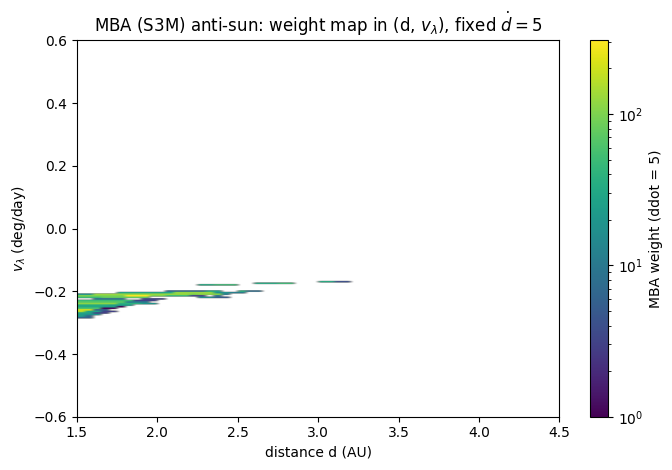

Peak weights: min=0.000e+00, max=3.060e+02


In [169]:

plt.figure(figsize=(7, 4))
plt.plot(d_grid, best_vlam, lw=2)
plt.axhline(0.0, lw=1)
plt.xlabel("distance d (AU)")
plt.ylabel(r"best-fit $v_\lambda$ (deg/day)  [$\dot d = 5$]")
plt.title("MBA (S3M) anti-sun: best $v_\\lambda$ vs distance (fixed $\dot d=5$)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.8))
plt.imshow(
    W.T,
    origin="lower",
    aspect="auto",
    extent=[d_grid[0], d_grid[-1], vlam_grid[0], vlam_grid[-1]],
    norm = "log"
)
# add norm = "log" to imshow to see in log space
plt.colorbar(label="MBA weight (ddot = 5)")
plt.xlabel("distance d (AU)")
plt.ylabel(r"$v_\lambda$ (deg/day)")
plt.title("MBA (S3M) anti-sun: weight map in (d, $v_\\lambda$), fixed $\dot d=5$")
plt.tight_layout()
plt.show()

print(f"Peak weights: min={best_w.min():.3e}, max={best_w.max():.3e}")


Extracting elements on ridge: 100%|██████████| 31/31 [00:00<00:00, 95.52d/s]


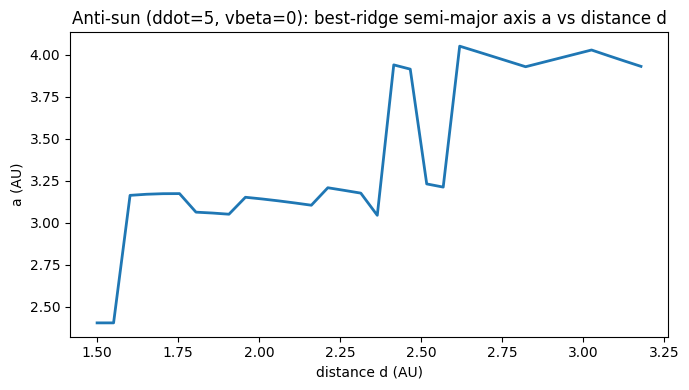

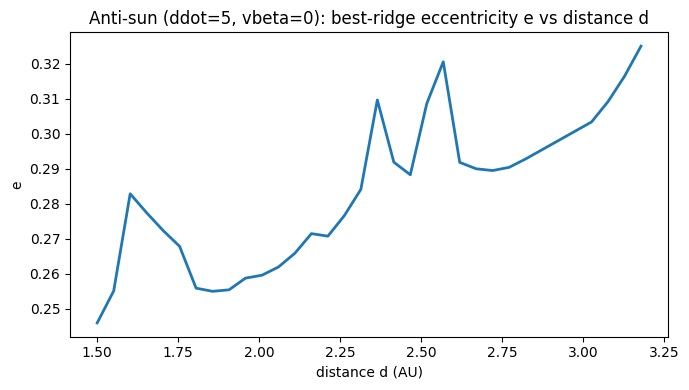

a range: 2.4049904038653134 to 4.050014525194253
e range: 0.2459372472296551 to 0.3250859654594112
i range: 0.004593556280109605 to 0.005189600097184111
H range: 20.0 to 20.0


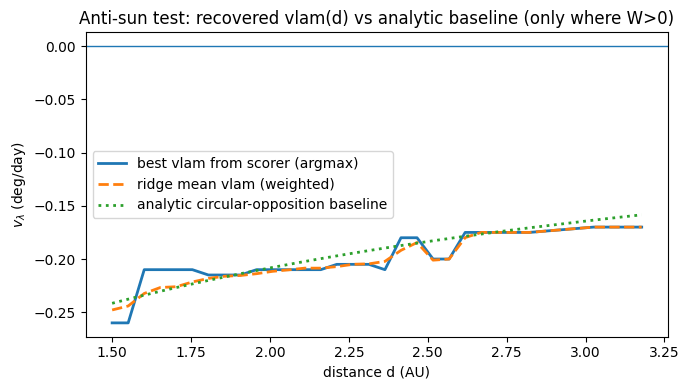

Supported d range: 1.5 to 3.1779661016949152
How many supported points: 31 / 60


In [170]:
# mask unsupported distances 
row_max = W.max(axis=1)
mask = row_max > 0

#for opposition, circular coplanar orbit
vE = 0.986  # deg/day
d = d_grid.copy()
R = 1.0 + d
vlam_pred = vE * (1/np.sqrt(R) - 1.0) / d  # deg/day, negative, |vlam| decreases with d

# using "center of mass" of the ridge instead of argmax
# this avoids bin/edge effects if the ridge is broad
Wpos = W.copy()
Wpos[Wpos < 0] = 0 # negative weight clipped to 0
vlam_mean = np.full(len(d_grid), np.nan)
for k in range(len(d_grid)):
    s = Wpos[k].sum()
    if s > 0:
        vlam_mean[k] = np.sum(vlam_grid * Wpos[k]) / s

# Extract orbital elements (a,e,i,H) along the best-vlam ridge vs distance 

a_best = np.full(len(d_grid), np.nan)
e_best = np.full(len(d_grid), np.nan)
i_best = np.full(len(d_grid), np.nan)
H_best = np.full(len(d_grid), np.nan)
score_best = np.full(len(d_grid), np.nan)

for k in tqdm(np.where(mask)[0], desc="Extracting elements on ridge", unit="d"):
    d_au = d_grid[k]
    vlam = best_vlam[k]

    # convert (vlam, vbeta_fixed) -> (dra, ddec) at the anti-sun sky position
    dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
        ra0_deg, dec0_deg, vlam, vbeta_fixed, obstime_str
    )

    out = scorer_mba_s3m.compute_score(
        obstime_str=obstime_str,
        ra_deg=ra0_deg,
        dec_deg=dec0_deg,
        dra_deg_per_day=dra,
        ddec_deg_per_day=ddec,
        mag=mag,
        d_au=d_au,
        ddot_kms=ddot_fixed
    )

    score_best[k] = out["score"]
    a_best[k] = out["a"]
    e_best[k] = out["e"]
    i_best[k] = out["i"]
    H_best[k] = out["H"]

# Plot a vs d (only where supported)
plt.figure(figsize=(7,4))
plt.plot(d_grid[mask], a_best[mask], lw=2)
plt.xlabel("distance d (AU)")
plt.ylabel("a (AU)")
plt.title("Anti-sun (ddot=5, vbeta=0): best-ridge semi-major axis a vs distance d")
plt.tight_layout()
plt.show()

# plotting e vs d
plt.figure(figsize=(7,4))
plt.plot(d_grid[mask], e_best[mask], lw=2)
plt.xlabel("distance d (AU)")
plt.ylabel("e")
plt.title("Anti-sun (ddot=5, vbeta=0): best-ridge eccentricity e vs distance d")
plt.tight_layout()
plt.show()



print("a range:", np.nanmin(a_best), "to", np.nanmax(a_best))
print("e range:", np.nanmin(e_best), "to", np.nanmax(e_best))
print("i range:", np.nanmin(i_best), "to", np.nanmax(i_best))
print("H range:", np.nanmin(H_best), "to", np.nanmax(H_best))


# plot comparison only where supported aka no zero
plt.figure(figsize=(7,4))
plt.plot(d_grid[mask], best_vlam[mask], lw=2, label="best vlam from scorer (argmax)")
plt.plot(d_grid[mask], vlam_mean[mask], lw=2, ls="--", label="ridge mean vlam (weighted)")
plt.plot(d_grid[mask], vlam_pred[mask], lw=2, ls=":", label="analytic circular-opposition baseline")

plt.axhline(0, lw=1)
plt.xlabel("distance d (AU)")
plt.ylabel(r"$v_\lambda$ (deg/day)")
plt.title("Anti-sun test: recovered vlam(d) vs analytic baseline (only where W>0)")
plt.legend()
plt.tight_layout()
plt.show()

print("Supported d range:", d_grid[mask].min(), "to", d_grid[mask].max())
print("How many supported points:", mask.sum(), "/", len(mask))


### same plots but for vbeta = 0.1 ddot = 0
##### changed my mind again vlam range and vbeta = 0.06

In [171]:
def anti_sun_radec_icrs(obstime_str):
    """Anti-sun RA/Dec in GCRS at obstime."""
    t = Time(obstime_str)
    sun = get_sun(t)
    cart = sun.cartesian
    anti = SkyCoord(
        x=-cart.x, y=-cart.y, z=-cart.z,
        representation_type="cartesian",
        frame="gcrs",
        obstime=t
    )
    return (
        anti.spherical.lon.to_value(u.deg),
        anti.spherical.lat.to_value(u.deg),
    )



ra0_deg, dec0_deg = anti_sun_radec_icrs(obstime_str)

print(f"obstime = {obstime_str}")
print(f"anti-sun RA,Dec (deg) = {ra0_deg:.6f}, {dec0_deg:.6f}")


# pick a representative ecliptic rate
vlam0, vbet0 = -0.2, 0.0  # deg/day

# forward: (vlam,vbet) -> (dra,ddec)
dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
    ra0_deg, dec0_deg, vlam0, vbet0, obstime_str
)

# backward: (dra,ddec) -> (vlam_back,vbet_back) at SAME obstime
vlam_back, vbet_back = radec_rates_to_ecliptic_rates_at_obstime(
    ra0_deg, dec0_deg, dra, ddec, obstime_str
)

print("vlam0:", vlam0)
print("vlam_back:", vlam_back)
print("diff (vlam_back - vlam0):", vlam_back - vlam0)
print("vbet0:", vbet0, "vbet_back:", vbet_back)



# Grids

d_grid = np.linspace(1.5, 4.5, 60)          # AU
vlam_grid = np.linspace(-0.6, 0.6, 241)     # deg/day
vbeta_fixed = 0.1
ddot_fixed = 0.0                            

W = np.zeros((len(d_grid), len(vlam_grid)), dtype=float)


# Scan with fixed ddot = 0

t0 = time.perf_counter()

for idd, d_au in enumerate(tqdm(d_grid, desc="Scanning distance d", unit="AU")):
    for iv, vlam in enumerate(vlam_grid):
        dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
            ra0_deg, dec0_deg, vlam, vbeta_fixed, obstime_str
        )

        out = scorer_mba_s3m.compute_score(
            obstime_str=obstime_str,
            ra_deg=ra0_deg,
            dec_deg=dec0_deg,
            dra_deg_per_day=dra,
            ddec_deg_per_day=ddec,
            mag=mag,
            d_au=d_au,
            ddot_kms=ddot_fixed
        )

        W[idd, iv] = out["score"]

t1 = time.perf_counter()
print(f"\nTotal runtime: {(t1 - t0)/60:.2f} minutes")


best_idx = np.argmax(W, axis=1)
best_vlam = vlam_grid[best_idx]
best_w = W[np.arange(len(d_grid)), best_idx]



obstime = 2025-09-23T00:00:00
anti-sun RA,Dec (deg) = 359.881947, -0.051431
vlam0: -0.2
vlam_back: -0.19995971318339506
diff (vlam_back - vlam0): 4.0286816604950815e-05
vbet0: 0.0 vbet_back: 3.113397578260749e-08


Scanning distance d: 100%|██████████| 60/60 [02:28<00:00,  2.47s/AU]


Total runtime: 2.47 minutes


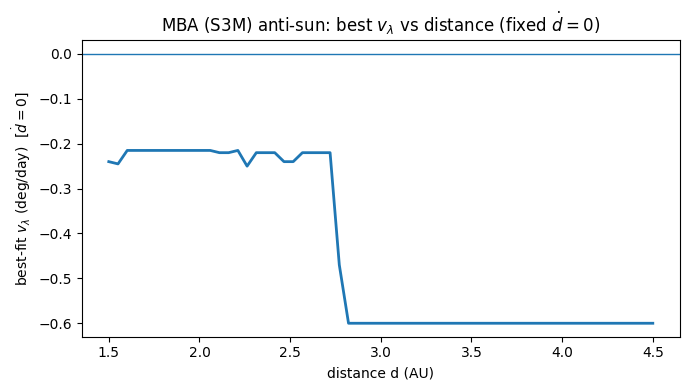

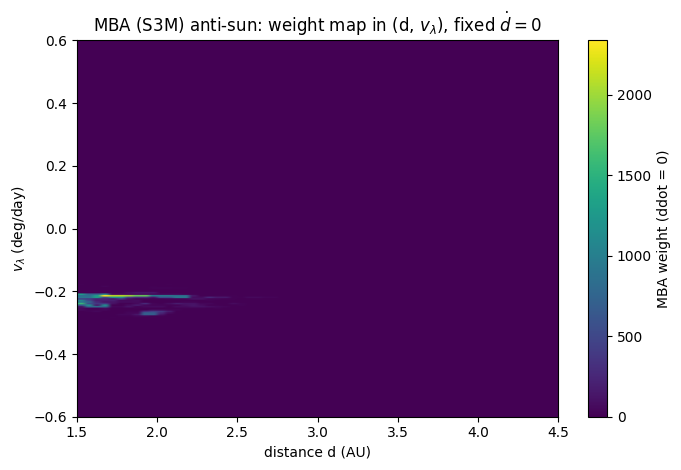

Peak weights: min=0.000e+00, max=2.337e+03


In [172]:

plt.figure(figsize=(7, 4))
plt.plot(d_grid, best_vlam, lw=2)
plt.axhline(0.0, lw=1)
plt.xlabel("distance d (AU)")
plt.ylabel(r"best-fit $v_\lambda$ (deg/day)  [$\dot d = 0$]")
plt.title("MBA (S3M) anti-sun: best $v_\\lambda$ vs distance (fixed $\dot d=0$)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.8))
plt.imshow(
    W.T,
    origin="lower",
    aspect="auto",
    extent=[d_grid[0], d_grid[-1], vlam_grid[0], vlam_grid[-1]]
)
plt.colorbar(label="MBA weight (ddot = 0)")
plt.xlabel("distance d (AU)")
plt.ylabel(r"$v_\lambda$ (deg/day)")
plt.title("MBA (S3M) anti-sun: weight map in (d, $v_\\lambda$), fixed $\dot d=0$")
plt.tight_layout()
plt.show()

print(f"Peak weights: min={best_w.min():.3e}, max={best_w.max():.3e}")


Extracting elements on ridge: 100%|██████████| 26/26 [00:00<00:00, 95.22d/s]


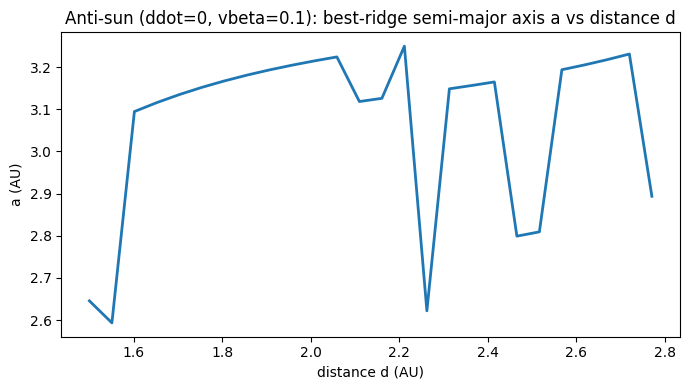

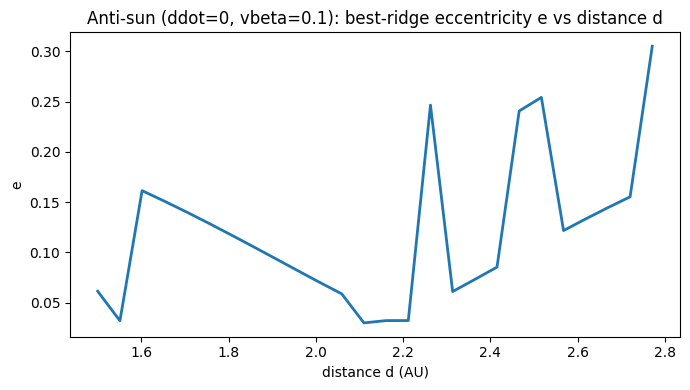

a range: 2.5935249019291997 to 3.2495015198415604
e range: 0.02983433498566632 to 0.3051312682055163
i range: 13.549291309223214 to 139.1234073001838
H range: 20.0 to 20.0


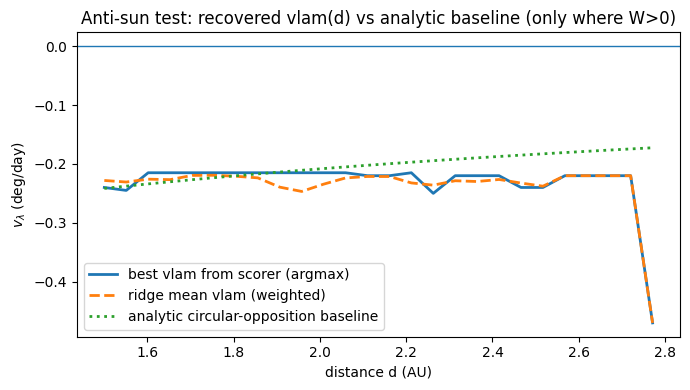

Supported d range: 1.5 to 2.7711864406779663
How many supported points: 26 / 60


In [173]:
# mask unsupported distances 
row_max = W.max(axis=1)
mask = row_max > 0

#for opposition, circular coplanar orbit
vE = 0.986  # deg/day
d = d_grid.copy()
R = 1.0 + d
vlam_pred = vE * (1/np.sqrt(R) - 1.0) / d  # deg/day, negative, |vlam| decreases with d

# using "center of mass" of the ridge instead of argmax
# this avoids bin/edge effects if the ridge is broad
Wpos = W.copy()
Wpos[Wpos < 0] = 0 # negative weight clipped to 0
vlam_mean = np.full(len(d_grid), np.nan)
for k in range(len(d_grid)):
    s = Wpos[k].sum()
    if s > 0:
        vlam_mean[k] = np.sum(vlam_grid * Wpos[k]) / s

# Extract orbital elements (a,e,i,H) along the best-vlam ridge vs distance

a_best = np.full(len(d_grid), np.nan)
e_best = np.full(len(d_grid), np.nan)
i_best = np.full(len(d_grid), np.nan)
H_best = np.full(len(d_grid), np.nan)
score_best = np.full(len(d_grid), np.nan)

for k in tqdm(np.where(mask)[0], desc="Extracting elements on ridge", unit="d"):
    d_au = d_grid[k]
    vlam = best_vlam[k]

    # convert (vlam, vbeta_fixed) -> (dra, ddec) at the anti-sun sky position
    dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
        ra0_deg, dec0_deg, vlam, vbeta_fixed, obstime_str
    )

    out = scorer_mba_s3m.compute_score(
        obstime_str=obstime_str,
        ra_deg=ra0_deg,
        dec_deg=dec0_deg,
        dra_deg_per_day=dra,
        ddec_deg_per_day=ddec,
        mag=mag,
        d_au=d_au,
        ddot_kms=ddot_fixed
    )

    score_best[k] = out["score"]
    a_best[k] = out["a"]
    e_best[k] = out["e"]
    i_best[k] = out["i"]
    H_best[k] = out["H"]

# Plot a vs d (only where supported)
plt.figure(figsize=(7,4))
plt.plot(d_grid[mask], a_best[mask], lw=2)
plt.xlabel("distance d (AU)")
plt.ylabel("a (AU)")
plt.title("Anti-sun (ddot=0, vbeta=0.1): best-ridge semi-major axis a vs distance d")
plt.tight_layout()
plt.show()

# plotting e vs d
plt.figure(figsize=(7,4))
plt.plot(d_grid[mask], e_best[mask], lw=2)
plt.xlabel("distance d (AU)")
plt.ylabel("e")
plt.title("Anti-sun (ddot=0, vbeta=0.1): best-ridge eccentricity e vs distance d")
plt.tight_layout()
plt.show()



print("a range:", np.nanmin(a_best), "to", np.nanmax(a_best))
print("e range:", np.nanmin(e_best), "to", np.nanmax(e_best))
print("i range:", np.nanmin(i_best), "to", np.nanmax(i_best))
print("H range:", np.nanmin(H_best), "to", np.nanmax(H_best))


# plot comparison only where supported aka no zero
plt.figure(figsize=(7,4))
plt.plot(d_grid[mask], best_vlam[mask], lw=2, label="best vlam from scorer (argmax)")
plt.plot(d_grid[mask], vlam_mean[mask], lw=2, ls="--", label="ridge mean vlam (weighted)")
plt.plot(d_grid[mask], vlam_pred[mask], lw=2, ls=":", label="analytic circular-opposition baseline")

plt.axhline(0, lw=1)
plt.xlabel("distance d (AU)")
plt.ylabel(r"$v_\lambda$ (deg/day)")
plt.title("Anti-sun test: recovered vlam(d) vs analytic baseline (only where W>0)")
plt.legend()
plt.tight_layout()
plt.show()

print("Supported d range:", d_grid[mask].min(), "to", d_grid[mask].max())
print("How many supported points:", mask.sum(), "/", len(mask))


#### im curious to see if vlam range, vbet = 0.004?

In [174]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import get_sun, SkyCoord
from tqdm import tqdm
import time



def anti_sun_radec_icrs(obstime_str):
    """Anti-sun RA/Dec in GCRS at obstime."""
    t = Time(obstime_str)
    sun = get_sun(t)
    cart = sun.cartesian
    anti = SkyCoord(
        x=-cart.x, y=-cart.y, z=-cart.z,
        representation_type="cartesian",
        frame="gcrs",
        obstime=t
    )
    return (
        anti.spherical.lon.to_value(u.deg),
        anti.spherical.lat.to_value(u.deg),
    )



ra0_deg, dec0_deg = anti_sun_radec_icrs(obstime_str)

print(f"obstime = {obstime_str}")
print(f"anti-sun RA,Dec (deg) = {ra0_deg:.6f}, {dec0_deg:.6f}")


# pick a representative ecliptic rate
vlam0, vbet0 = -0.3, 0.006  # deg/day

# forward: (vlam,vbet) -> (dra,ddec)
dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
    ra0_deg, dec0_deg, vlam0, vbet0, obstime_str
)

# backward: (dra,ddec) -> (vlam_back,vbet_back) at SAME obstime
vlam_back, vbet_back = radec_rates_to_ecliptic_rates_at_obstime(
    ra0_deg, dec0_deg, dra, ddec, obstime_str
)

print("vlam0:", vlam0)
print("vlam_back:", vlam_back)
print("diff (vlam_back - vlam0):", vlam_back - vlam0)
print("vbet0:", vbet0, "vbet_back:", vbet_back)



# Grids

d_grid = np.linspace(1.5, 4.5, 60)          # AU
vlam_grid = np.linspace(-0.6, 0.6, 241)     # deg/day
vbeta_fixed = 0.004
ddot_fixed = 0.0                            

W = np.zeros((len(d_grid), len(vlam_grid)), dtype=float)


# Scan with fixed ddot = 0

t0 = time.perf_counter()

for idd, d_au in enumerate(tqdm(d_grid, desc="Scanning distance d", unit="AU")):
    for iv, vlam in enumerate(vlam_grid):
        dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
            ra0_deg, dec0_deg, vlam, vbeta_fixed, obstime_str
        )

        out = scorer_mba_s3m.compute_score(
            obstime_str=obstime_str,
            ra_deg=ra0_deg,
            dec_deg=dec0_deg,
            dra_deg_per_day=dra,
            ddec_deg_per_day=ddec,
            mag=mag,
            d_au=d_au,
            ddot_kms=ddot_fixed
        )

        W[idd, iv] = out["score"]

t1 = time.perf_counter()
print(f"\nTotal runtime: {(t1 - t0)/60:.2f} minutes")


best_idx = np.argmax(W, axis=1)
best_vlam = vlam_grid[best_idx]
best_w = W[np.arange(len(d_grid)), best_idx]



obstime = 2025-09-23T00:00:00
anti-sun RA,Dec (deg) = 359.881947, -0.051431
vlam0: -0.3
vlam_back: -0.29995971319058307
diff (vlam_back - vlam0): 4.0286809416922864e-05
vbet0: 0.006 vbet_back: 0.006000031135857914


Scanning distance d: 100%|██████████| 60/60 [02:29<00:00,  2.49s/AU]


Total runtime: 2.49 minutes


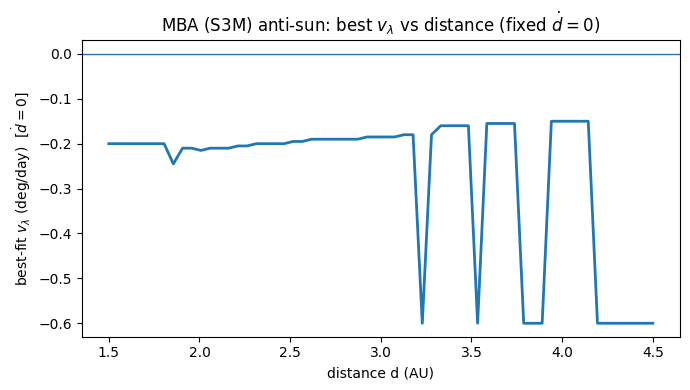

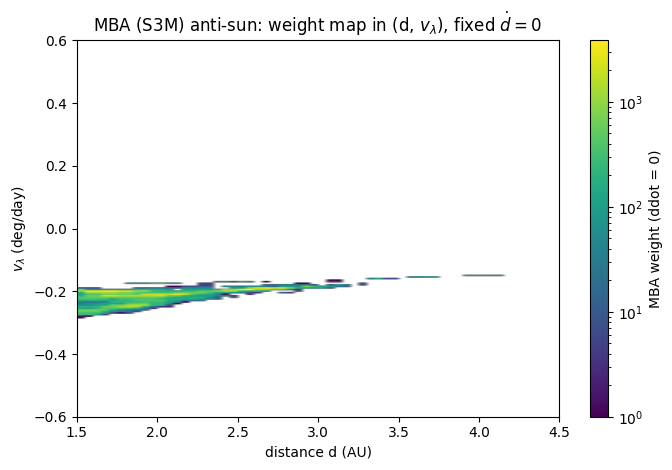

Peak weights: min=0.000e+00, max=3.846e+03


In [175]:

plt.figure(figsize=(7, 4))
plt.plot(d_grid, best_vlam, lw=2)
plt.axhline(0.0, lw=1)
plt.xlabel("distance d (AU)")
plt.ylabel(r"best-fit $v_\lambda$ (deg/day)  [$\dot d = 0$]")
plt.title("MBA (S3M) anti-sun: best $v_\\lambda$ vs distance (fixed $\dot d=0$)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.8))
plt.imshow(
    W.T,
    origin="lower",
    aspect="auto",
    extent=[d_grid[0], d_grid[-1], vlam_grid[0], vlam_grid[-1]],
    norm = "log"
)
plt.colorbar(label="MBA weight (ddot = 0)")
plt.xlabel("distance d (AU)")
plt.ylabel(r"$v_\lambda$ (deg/day)")
plt.title("MBA (S3M) anti-sun: weight map in (d, $v_\\lambda$), fixed $\dot d=0$")
plt.tight_layout()
plt.show()

print(f"Peak weights: min={best_w.min():.3e}, max={best_w.max():.3e}")


Extracting elements on ridge: 100%|██████████| 48/48 [00:00<00:00, 95.91d/s]


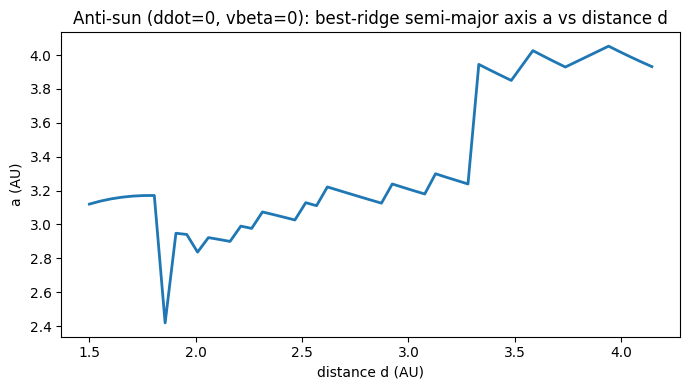

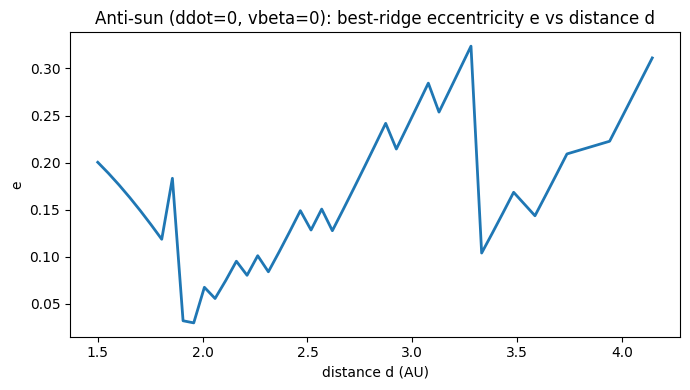

a range: 2.4186873340034647 to 4.052830078072638
e range: 0.02990162918311764 to 0.3235915828969716
i range: 0.5011536349733925 to 2.625995216611599
H range: 20.0 to 20.0


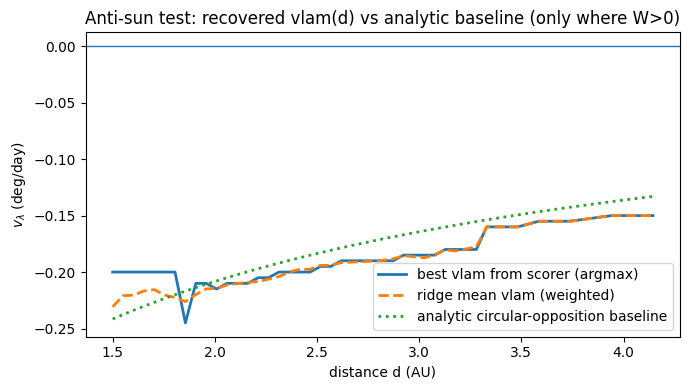

Supported d range: 1.5 to 4.1440677966101696
How many supported points: 48 / 60


In [176]:
# mask unsupported distances 
row_max = W.max(axis=1)
mask = row_max > 0

#for opposition, circular coplanar orbit
vE = 0.986  # deg/day
d = d_grid.copy()
R = 1.0 + d
vlam_pred = vE * (1/np.sqrt(R) - 1.0) / d  # deg/day, negative, |vlam| decreases with d

# using "center of mass" of the ridge instead of argmax
# this avoids bin/edge effects if the ridge is broad
Wpos = W.copy()
Wpos[Wpos < 0] = 0 # negative weight clipped to 0
vlam_mean = np.full(len(d_grid), np.nan)
for k in range(len(d_grid)):
    s = Wpos[k].sum()
    if s > 0:
        vlam_mean[k] = np.sum(vlam_grid * Wpos[k]) / s

# Extract orbital elements (a,e,i,H) along the best-vlam ridge vs distance 

a_best = np.full(len(d_grid), np.nan)
e_best = np.full(len(d_grid), np.nan)
i_best = np.full(len(d_grid), np.nan)
H_best = np.full(len(d_grid), np.nan)
score_best = np.full(len(d_grid), np.nan)

for k in tqdm(np.where(mask)[0], desc="Extracting elements on ridge", unit="d"):
    d_au = d_grid[k]
    vlam = best_vlam[k]

    # convert (vlam, vbeta_fixed) -> (dra, ddec) at the anti-sun sky position
    dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
        ra0_deg, dec0_deg, vlam, vbeta_fixed, obstime_str
    )

    out = scorer_mba_s3m.compute_score(
        obstime_str=obstime_str,
        ra_deg=ra0_deg,
        dec_deg=dec0_deg,
        dra_deg_per_day=dra,
        ddec_deg_per_day=ddec,
        mag=mag,
        d_au=d_au,
        ddot_kms=ddot_fixed
    )

    score_best[k] = out["score"]
    a_best[k] = out["a"]
    e_best[k] = out["e"]
    i_best[k] = out["i"]
    H_best[k] = out["H"]

# Plot a vs d (only where supported)
plt.figure(figsize=(7,4))
plt.plot(d_grid[mask], a_best[mask], lw=2)
plt.xlabel("distance d (AU)")
plt.ylabel("a (AU)")
plt.title("Anti-sun (ddot=0, vbeta=0): best-ridge semi-major axis a vs distance d")
plt.tight_layout()
plt.show()

# plotting e vs d
plt.figure(figsize=(7,4))
plt.plot(d_grid[mask], e_best[mask], lw=2)
plt.xlabel("distance d (AU)")
plt.ylabel("e")
plt.title("Anti-sun (ddot=0, vbeta=0): best-ridge eccentricity e vs distance d")
plt.tight_layout()
plt.show()



print("a range:", np.nanmin(a_best), "to", np.nanmax(a_best))
print("e range:", np.nanmin(e_best), "to", np.nanmax(e_best))
print("i range:", np.nanmin(i_best), "to", np.nanmax(i_best))
print("H range:", np.nanmin(H_best), "to", np.nanmax(H_best))


# plot comparison only where supported aka no zero
plt.figure(figsize=(7,4))
plt.plot(d_grid[mask], best_vlam[mask], lw=2, label="best vlam from scorer (argmax)")
plt.plot(d_grid[mask], vlam_mean[mask], lw=2, ls="--", label="ridge mean vlam (weighted)")
plt.plot(d_grid[mask], vlam_pred[mask], lw=2, ls=":", label="analytic circular-opposition baseline")

plt.axhline(0, lw=1)
plt.xlabel("distance d (AU)")
plt.ylabel(r"$v_\lambda$ (deg/day)")
plt.title("Anti-sun test: recovered vlam(d) vs analytic baseline (only where W>0)")
plt.legend()
plt.tight_layout()
plt.show()

print("Supported d range:", d_grid[mask].min(), "to", d_grid[mask].max())
print("How many supported points:", mask.sum(), "/", len(mask))
